In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving processed_courses.csv to processed_courses.csv


In [ ]:
courses = pd.read_csv("processed_courses.csv")
courses

,name,institution,course_id,reviews,rating
0,machine learning,stanford university,machine-learning,this is an extremely basic course. machine lea...,1
1,machine learning,stanford university,machine-learning,the course is ok but the certification procedu...,1
2,machine learning,stanford university,machine-learning,"i just started week 3 , i have to admit that i...",1
3,machine learning,stanford university,machine-learning,this course is absolute garbage. you get no fe...,1
4,machine learning,stanford university,machine-learning,"however good the material and lectures may be,...",1
...,...,...,...,...,...
456844,managing as a coach,"university of california, davis",managing-as-a-coach,great learning!!!,5
456845,managing as a coach,"university of california, davis",managing-as-a-coach,excellent course.,5
456846,managing as a coach,"university of california, davis",managing-as-a-coach,good to attempt!!,5
456847,managing as a coach,"university of california, davis",managing-as-a-coach,excellent course!,5


In [ ]:
print("Shape:", courses.shape)

Shape: (456849, 5)


In [ ]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456849 entries, 0 to 456848
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   name         456849 non-null  object
 1   institution  456849 non-null  object
 2   course_id    456849 non-null  object
 3   reviews      456849 non-null  object
 4   rating       456849 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 17.4+ MB


In [ ]:
courses.head()

,name,institution,course_id,reviews,rating
0,machine learning,stanford university,machine-learning,this is an extremely basic course. machine lea...,1
1,machine learning,stanford university,machine-learning,the course is ok but the certification procedu...,1
2,machine learning,stanford university,machine-learning,"i just started week 3 , i have to admit that i...",1
3,machine learning,stanford university,machine-learning,this course is absolute garbage. you get no fe...,1
4,machine learning,stanford university,machine-learning,"however good the material and lectures may be,...",1


In [ ]:
courses.describe(include="all")

,name,institution,course_id,reviews,rating
count,456849,456849,456849,456849,456849.000000
unique,603,132,604,439600,NaN
top,programming for everybody (getting started wit...,university of michigan,python,excellent course,NaN
freq,14200,49686,14200,363,NaN
mean,NaN,NaN,NaN,NaN,4.674396
std,NaN,NaN,NaN,NaN,0.728405
min,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,5.000000
50%,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,5.000000


In [ ]:
courses.isnull().sum()

,0
name,0
institution,0
course_id,0
reviews,0
rating,0


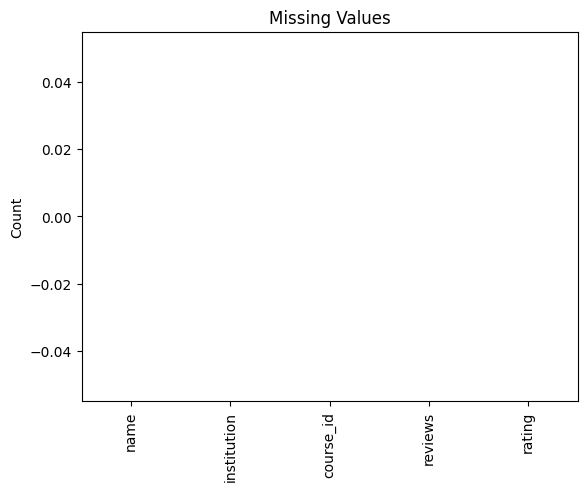

In [ ]:
courses.isnull().sum().plot(kind="bar")
plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

In [ ]:
print("Duplicate Rows:", courses.duplicated().sum())

Duplicate Rows: 0


In [ ]:
courses["rating"].value_counts().sort_index()

,count
rating,
1,6161
2,5832
3,16575
4,73462
5,354819


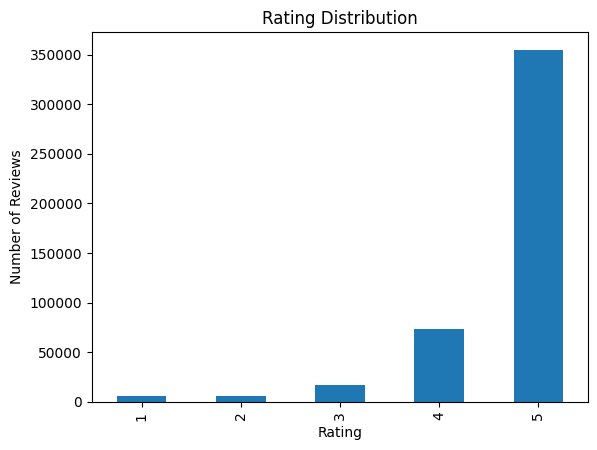

In [ ]:
courses["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
top_inst = courses["institution"].value_counts().head(10)

print(top_inst)

institution
university of michigan                49686
deeplearning.ai                       36285
google                                23392
university of pennsylvania            23106
stanford university                   22043
ibm                                   21448
university of california san diego    20163
yale university                       17904
johns hopkins university              17364
duke university                       14297
Name: count, dtype: int64


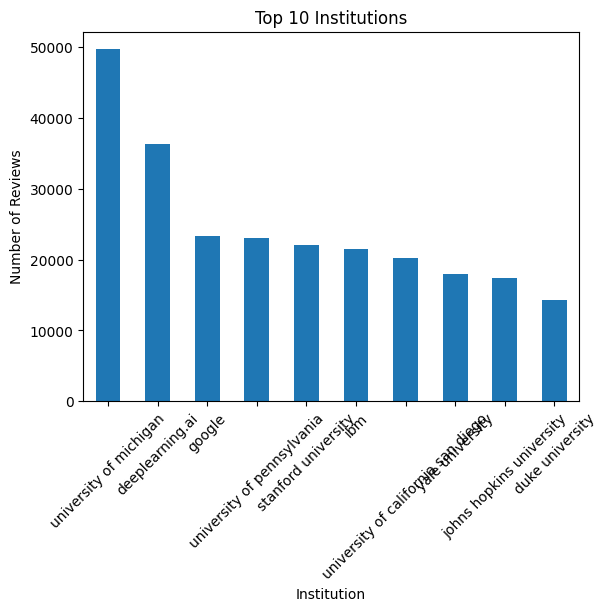

In [ ]:
top_inst.plot(kind="bar")

plt.title("Top 10 Institutions")
plt.xlabel("Institution")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_courses = courses["name"].value_counts().head(10)

print(top_courses)

name
programming for everybody (getting started with python)                           14200
machine learning                                                                  12506
neural networks and deep learning                                                 12179
learning how to learn: powerful mental tools to help you master tough subjects    11686
technical support fundamentals                                                    11245
python data structures                                                            10077
the science of well-being                                                          7645
excel skills for business: essentials                                              6403
what is data science?                                                              6360
ai for everyone                                                                    6144
Name: count, dtype: int64


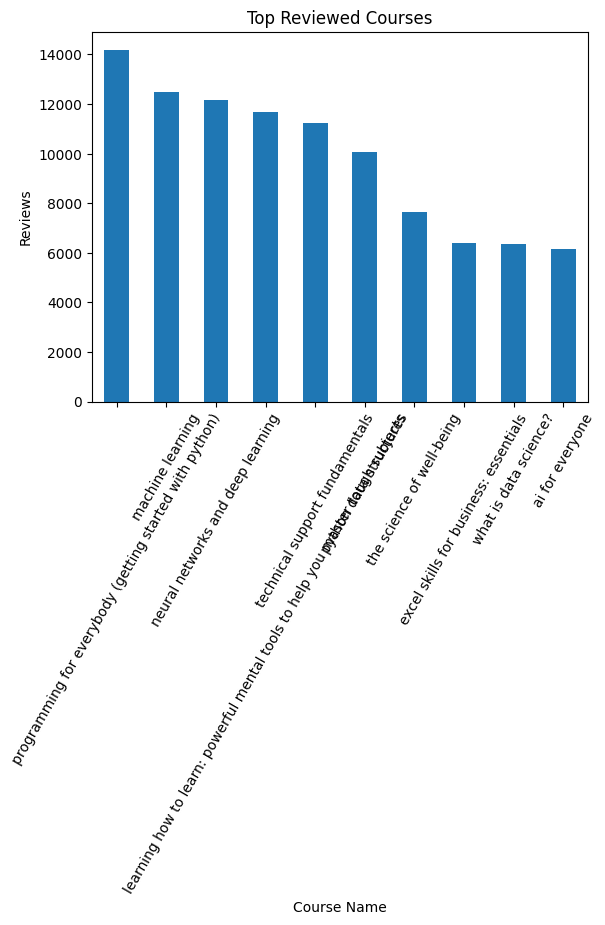

In [ ]:
top_courses.plot(kind="bar")

plt.title("Top Reviewed Courses")
plt.xlabel("Course Name")
plt.ylabel("Reviews")
plt.xticks(rotation=60)
plt.show()

In [ ]:
print("Unique Courses:", courses["name"].nunique())

Unique Courses: 603


In [ ]:
print("Unique Institutions:", courses["institution"].nunique())

Unique Institutions: 132


In [ ]:
courses["review_length"] = courses["reviews"].str.len()

In [ ]:
courses["review_length"].describe()

,review_length
count,456849.000000
mean,148.075596
std,163.230715
min,3.000000
25%,52.000000
50%,100.000000
75%,187.000000
max,7787.000000


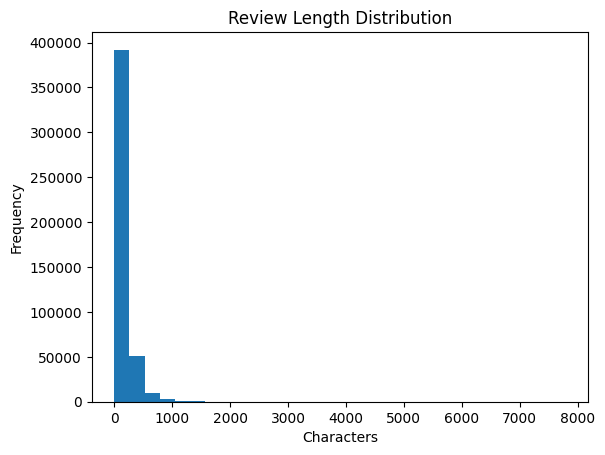

In [ ]:
courses["review_length"].plot(kind="hist", bins=30)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.show()

In [ ]:
avg_rating = courses.groupby("institution")["rating"].mean()

avg_rating.sort_values(ascending=False).head(10)

,rating
institution,
gitlab,5.000000
university of rochester,4.926471
universidade estadual de campinas,4.919725
arizona state university,4.903120
hebrew university of jerusalem,4.899338
the university of chicago,4.893390
universidad de los andes,4.890101
sas,4.886525
university of arizona,4.883081


In [ ]:
course_rating = courses.groupby("name")["rating"].mean()

course_rating.sort_values(ascending=False).head(10)

,rating
name,
building modern python applications on aws,5.000000
removing barriers to change,5.000000
entreprise et changement climatique,5.000000
how to manage a remote team,5.000000
el abogado del futuro: legaltech y la transformación digital del derecho,4.966667
bugs 101: insect-human interactions,4.964539
build a modern computer from first principles: nand to tetris part ii (project-centered course),4.954023
"everyday excel, part 2",4.944444
everyday parenting: the abcs of child rearing,4.932849


In [ ]:
review_count = courses.groupby("name").size()

review_count.sort_values(ascending=False).head(10)

,0
name,
programming for everybody (getting started with python),14200
machine learning,12506
neural networks and deep learning,12179
learning how to learn: powerful mental tools to help you master tough subjects,11686
technical support fundamentals,11245
python data structures,10077
the science of well-being,7645
excel skills for business: essentials,6403
what is data science?,6360


In [ ]:
courses.to_csv("eda_courses.csv", index=False)

In [ ]:
from google.colab import files

files.download("eda_courses.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>